# Lateral-drag performance audit for Antarctic fast-ice formation

This notebook is a process-based diagnostic scaffold for the **lateral-drag** experiments. It deliberately treats **binary-days fast-ice classification** and derived `shuga` metrics as the outcome layer, then adds dynamical diagnostics from the CICE history fields: *force-budget proxies*, *stress ratios*, *strain/speed phase space*, *formation-retention-breakout timing*, *spatial skill against `AF2020`*, *distance-to-anchor diagnostics*, and a *final scorecard*.

The notebook assumes the current gadi layout and `shuga` package in `~/AFIM/src/mawsons-chest`. It is written so that most cells degrade gracefully when individual variables are absent from older experiments.

## 0. Setup, imports, and common configuration

The analysis windows below defaults to 1993 because that is the common period across the short `blend-strain` experiments. Later I will move to other years.


In [1]:
from __future__ import annotations
import os
import sys
import shutil
import subprocess
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Mapping, Sequence
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display, Image, Video
# ---------------------------------------------------------------------
repo_root = Path.home() / "AFIM" / "src" / "mawsons-chest"
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from shuga import (RunSpec,
                   ClassificationSpec,
                   MetricsSpec,
                   ShugaPaths,
                   CICEPlotter,
                   SeaIceObservations,
                   load_cice,
                   load_classified,
                   load_metrics,
                   report_sim_status)

### Analysis controls.

In [3]:
RHO_ICE           = 917.0  # kg m-3; used only for estimated lateral-drag stress if Kux/Kuy are accelerations
EPS               = 1.0e-30
PROJECT           = "gv90"
USER              = "da1339"
HEMISPHERE        = "SH"
ICE_TYPE          = "FI"
GRID_TYPE         = "Tc"
METHOD            = "binary-days"
ISPD_THRESH       = 5.0e-4
BIN_WINDOW        = 11
BIN_MIN_DAYS      = 9
ROLL_WINDOW       = 15
COMMON_START      = "1994-01-01"
COMMON_END        = "1994-12-31"
FORMATION_START   = "1994-04-01"
FORMATION_END     = "1994-08-31"
RETREAT_START     = "1994-11-01"
RETREAT_END       = "1994-12-31"
# Keep the first pass light. Increase after smoke-testing the notebook.
DIAG_START        = "1994-10-01"
DIAG_END          = "1994-12-31"
REGION_NAME       = "Aus"       # good first diagnostic region; change to DML/WIO/EIO/VOL/AS/BS/WS/SH as needed
SAMPLE_FRAC       = 0.02          # for phase-space scatter; 0.01--0.05 is usually plenty
RNG_SEED          = 42
SAVE_FIGS         = True
SHOW_FIGS         = True
# External form-factor file used in older notebooks. The current CICE history also includes F2E/F2N for many runs.
FORM_FACTOR_FILE  = Path("/g/data/gv90/da1339/coastal_drag/form_factors/ADD_high-res_cstln_v7p9_GI_CICE_free-slip.nc")
AFIM_OUTPUT_ROOT  = Path(f"/g/data/{PROJECT}/{USER}/afim_output")
AFIM_ARCHIVE_ROOT = Path.home() / "AFIM_archive"
GRAPHICS_ROOT     = Path(f"/g/data/{PROJECT}/{USER}/GRAPHICAL/")
NOTEBOOK_FIG_ROOT = GRAPHICS_ROOT / "lateral_drag_process_audit"
NOTEBOOK_FIG_ROOT.mkdir(parents=True, exist_ok=True)
xr.set_options(keep_attrs=True)
warnings.filterwarnings("default")
print(f"Using repo_root={repo_root}")
print(f"Figures -> {NOTEBOOK_FIG_ROOT}")
# Simulation groupings. These are intentionally editable.
CORE_SIMS          = ["LD-static-Cs1e-3",
                      "LD-quad-Cq700",
                      "LD-blend-base",
                      "LD-blend-sharp",
                      "LD-blend-smooth",
                      "LD-blend-speed-strict",
                      "LD-blend-speed-permissive",
                      "LD-blend-strain-permissive"]
BLEND_SIMS         = ["LD-blend-base", "LD-blend-sharp", "LD-blend-smooth", "LD-blend-speed-strict", "LD-blend-speed-permissive", "LD-blend-strain-permissive"]
STATIC_SIMS        = ["LD-static-Cs2p5e-4", "LD-static-Cs5e-4", "LD-static-Cs7p5e-4", "LD-static-Cs1e-3"]
QUAD_SIMS          = ["LD-quad-Cq70", "LD-quad-Cq700"]
LINEAR_SIMS        = ["LD-linear-CL0p1", "LD-linear-CL0p25", "LD-linear-CL0p5"]
ALL_CANDIDATE_SIMS = sorted(set(CORE_SIMS + BLEND_SIMS + STATIC_SIMS + QUAD_SIMS + LINEAR_SIMS + ["LD-om3", "LD-tides"]))
# Approximate availability from the current directory listings. The introspection helpers below are preferred.
KNOWN_AVAILABILITY = {"LD-blend-base"              : ("1994-09", "1994-12"),
                      "LD-blend-smooth"            : ("1994-09", "1994-12"),
                      "LD-blend-sharp"             : ("1994-09", "1994-12"),
                      "LD-blend-speed-strict"      : ("1994-09", "1994-12"),
                      "LD-blend-speed-permissive"  : ("1994-09", "1994-12"),
                      "LD-blend-strain-permissive" : ("1994-09", "1994-12"),
                      "LD-linear-CL0p1"            : ("1993-01", "2009-10"),
                      "LD-linear-CL0p25"           : ("1993-01", "2023-12"),
                      "LD-linear-CL0p5"            : ("1993-01", "2012-10"),
                      "LD-om3"                     : ("1993-01", "1995-12"),
                      "LD-quad-Cq70"               : ("1993-01", "2010-12"),
                      "LD-quad-Cq700"              : ("1993-01", "2003-12"),
                      "LD-static-Cs2p5e-4"         : ("1993-01", "2010-10"),
                      "LD-static-Cs5e-4"           : ("1993-01", "2019-12"),
                      "LD-static-Cs7p5e-4"         : ("1993-01", "2018-12"),
                      "LD-static-Cs1e-3"           : ("1993-01", "2023-06"),
                      "LD-tides"                   : ("1993-01", "1993-12")}
OUTCOME_DYN_VARS = ["aice", "hi", "tarea", "TLON", "TLAT",
                    "uvel", "vvel", "uocn", "vocn", "uatm", "vatm",
                    "divu", "shear", "sig1", "sig2", "sigP", "strength",
                    "strairx", "strairy", "strocnx", "strocny", "strintx", "strinty",
                    "strcorx", "strcory", "strtltx", "strtlty",
                    "KuxE", "KuxN", "KuyE", "KuyN", "ld"]

Using repo_root=/home/581/da1339/AFIM/src/mawsons-chest
Figures -> /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit


## 0.1 Helper functions

These helpers sit between raw shuga loaders and the diagnostics. They keep the section code compact and make the notebook tolerant of missing variables.


In [3]:
def make_run(sim_name: str, start: str = COMMON_START, end: str = COMMON_END) -> RunSpec:
    return RunSpec(sim_name   = sim_name,
                   start_date = start,
                   end_date   = end,
                   hemisphere = HEMISPHERE,
                   project    = PROJECT,
                   user       = USER)

def make_classify(methods: Sequence[str] = (METHOD,)) -> ClassificationSpec:
    return ClassificationSpec(ice_type     = ICE_TYPE,
                              grid_type    = GRID_TYPE,
                              ispd_thresh  = ISPD_THRESH,
                              methods      = tuple(methods),
                              bin_window   = BIN_WINDOW,
                              bin_min_days = BIN_MIN_DAYS,
                              roll_window  = ROLL_WINDOW)

def list_month_groups(sim_name: str, root: Path = AFIM_ARCHIVE_ROOT) -> list[str]:
    zroot = root / sim_name / "zarr" / "iceh_daily.zarr"
    if not zroot.exists():
        # fall back to afim_output layout
        zroot = AFIM_OUTPUT_ROOT / sim_name / "zarr" / "iceh_daily.zarr"
    if not zroot.exists():
        return []
    return sorted(p.name for p in zroot.iterdir() if p.is_dir() and len(p.name) == 7 and p.name[4] == "-")

def list_group_variables(sim_name: str, group: str = "1993-10", root: Path = AFIM_ARCHIVE_ROOT) -> list[str]:
    zroot = root / sim_name / "zarr" / "iceh_daily.zarr" / group
    if not zroot.exists():
        zroot = AFIM_OUTPUT_ROOT / sim_name / "zarr" / "iceh_daily.zarr" / group
    if not zroot.exists():
        return []
    skip = {".", "..", ".zattrs", ".zgroup", ".zmetadata", "zarr.json"}
    return sorted(p.name for p in zroot.iterdir() if p.is_dir() and p.name not in skip)

def experiment_inventory(sims: Sequence[str] = ALL_CANDIDATE_SIMS, group: str = "1993-10") -> pd.DataFrame:
    rows = []
    for sim in sims:
        groups = list_month_groups(sim)
        vars_  = list_group_variables(sim, group=group)
        rows.append({"sim_name"         : sim,
                     "first_month"      : groups[0] if groups else np.nan,
                     "last_month"       : groups[-1] if groups else np.nan,
                     "n_months"         : len(groups),
                     "group_checked"    : group,
                     "n_vars_in_group"  : len(vars_),
                     "has_Ku_proxy"     : any(v in vars_ for v in ["KuxE", "KuxN", "KuyE", "KuyN"]),
                     "has_ocean_stress" : all(v in vars_ for v in ["strocnx", "strocny"]),
                     "has_coriolis"     : all(v in vars_ for v in ["strcorx", "strcory"]),
                     "has_tilt"         : all(v in vars_ for v in ["strtltx", "strtlty"]),
                     "sample_variables" : ", ".join(vars_[:18]) + (" ..." if len(vars_) > 18 else "")})
    return pd.DataFrame(rows)

def safe_load_cice(sim_name: str, start: str, end: str,
                   variables       : Sequence[str] | None = None, *,
                   chunks          : dict | None = None,
                   afim_output_root: Path | str | None = None,
                   cice_store      : Path | str | None = None,
                   static_store    : Path | str | None = None) -> xr.Dataset:
    run      = make_run(sim_name, start, end)
    classify = make_classify()
    return load_cice(run              = run,
                     classify         = classify,
                     variables        = list(variables) if variables is not None else None,
                     hemisphere       = HEMISPHERE,
                     chunks           = chunks or {"time": 31},
                     afim_output_root = afim_output_root,
                     cice_store       = cice_store,
                     static_store     = static_store)

def safe_load_classified(sim_name: str, start: str, end: str,
                         variables: Sequence[str] | None = ("FI_mask",), *,
                         method: str = METHOD,
                         chunks: dict | None = None) -> xr.Dataset:
    run      = make_run(sim_name, start, end)
    classify = make_classify((method,))
    return load_classified(run            = run,
                           classify       = classify,
                           classification = method,
                           variables      = list(variables) if variables is not None else None,
                           hemisphere     = HEMISPHERE,
                           grid_type      = GRID_TYPE,
                           chunks         = chunks or {"time": 31})

def safe_load_metrics(sim_name: str, start: str, end: str, *, method: str = METHOD, chunks: dict | None = None) -> xr.Dataset:
    run      = make_run(sim_name, start, end)
    classify = make_classify((method,))
    return load_metrics(run            = run,
                        classify       = classify,
                        classification = method,
                        hemisphere     = HEMISPHERE,
                        grid_type      = GRID_TYPE,
                        chunks         = chunks or {"time": 31})

def mag(ds: xr.Dataset | Mapping[str, xr.DataArray], x: str, y: str, name: str | None = None) -> xr.DataArray | None:
    if x in ds and y in ds:
        out = xr.apply_ufunc(np.hypot, ds[x], ds[y], dask="allowed")
        if name:
            out = out.rename(name)
        return out
    return None

def first_present(ds: xr.Dataset, candidates: Sequence[str]) -> str | None:
    return next((v for v in candidates if v in ds), None)

def area_da(ds: xr.Dataset) -> xr.DataArray:
    for name in ("tarea", "uarea", "narea", "earea"):
        if name in ds:
            return ds[name]
    raise KeyError("No recognised area field found. Expected one of tarea/uarea/narea/earea.")

def ice_speed(ds: xr.Dataset) -> xr.DataArray:
    out = mag(ds, "uvel", "vvel", "ice_speed")
    if out is None:
        raise KeyError("uvel/vvel are required for ice_speed.")
    out.attrs.update(units="m s-1", long_name="Ice speed")
    return out

def rel_ice_ocean_speed(ds: xr.Dataset) -> xr.DataArray | None:
    if all(v in ds for v in ["uvel", "vvel", "uocn", "vocn"]):
        out = xr.apply_ufunc(np.hypot, ds["uvel"] - ds["uocn"], ds["vvel"] - ds["vocn"], dask="allowed")
        out = out.rename("rel_ice_ocean_speed")
        out.attrs.update(units="m s-1", long_name="Relative ice-ocean speed")
        return out
    return None

def strain_invariant(ds: xr.Dataset) -> xr.DataArray | None:
    """Prefer existing CICE invariants. Fallback to sqrt(divu^2 + shear^2)."""
    if "sigP" in ds:
        return ds["sigP"].rename("strain_invariant")
    if all(v in ds for v in ["divu", "shear"]):
        return xr.apply_ufunc(np.hypot, ds["divu"], ds["shear"], dask="allowed").rename("strain_invariant")
    if "shear" in ds:
        return abs(ds["shear"]).rename("strain_invariant")
    return None

def ku_proxy(ds: xr.Dataset) -> xr.Dataset:
    """
    Return a dataset containing lateral-drag coefficient/acceleration proxies.

    The current history files expose edge-oriented variables such as KuxE/KuyE and
    KuxN/KuyN. This helper averages available edge fields to a T-grid-like proxy.
    Verify exact units/sign in the branch before treating tau_ld_est as a formal stress.
    """
    out      = xr.Dataset()
    x_fields = [v for v in ("KuxE", "KuxN") if v in ds]
    y_fields = [v for v in ("KuyE", "KuyN") if v in ds]
    if x_fields:
        out["ld_x_proxy"] = xr.concat([ds[v] for v in x_fields], dim="edge_x").mean("edge_x")
    if y_fields:
        out["ld_y_proxy"] = xr.concat([ds[v] for v in y_fields], dim="edge_y").mean("edge_y")
    if "ld_x_proxy" in out and "ld_y_proxy" in out:
        out["ld_mag_proxy"] = xr.apply_ufunc(np.hypot, out["ld_x_proxy"], out["ld_y_proxy"], dask="allowed")
    elif "ld_x_proxy" in out:
        out["ld_mag_proxy"] = abs(out["ld_x_proxy"])
    elif "ld_y_proxy" in out:
        out["ld_mag_proxy"] = abs(out["ld_y_proxy"])
    if "ld_mag_proxy" in out:
        out["ld_mag_proxy"].attrs.update(long_name="Lateral-drag K/acceleration proxy from Kux/Kuy history fields")
    return out

def compute_diagnostic_terms(ds: xr.Dataset) -> xr.Dataset:
    """Build a compact diagnostic dataset from one experiment's CICE history fields."""
    out = xr.Dataset(coords={k: v for k, v in ds.coords.items() if k in ("time", "ni", "nj")})
    if all(v in ds for v in ["uvel", "vvel"]):
        out["ice_speed"] = ice_speed(ds)
    rel = rel_ice_ocean_speed(ds)
    if rel is not None:
        out["rel_ice_ocean_speed"] = rel
    strain = strain_invariant(ds)
    if strain is not None:
        out["strain_invariant"] = strain
    for label, x, y in [("tau_air", "strairx", "strairy"),
                        ("tau_ocean", "strocnx", "strocny"),
                        ("tau_internal", "strintx", "strinty"),
                        ("tau_coriolis", "strcorx", "strcory"),
                        ("tau_tilt", "strtltx", "strtlty")]:
        z = mag(ds, x, y, label)
        if z is not None:
            out[label] = z
            out[label].attrs.update(units="nominal Pa", long_name=label)
    ku = ku_proxy(ds)
    for v in ku.data_vars:
        out[v] = ku[v]
    if "ld_mag_proxy" in out and "hi" in ds:
        # If Kux/Kuy are accelerations [m s-2], rho_i * hi * K gives Pa.
        h_eff = ds["hi"] * ds.get("aice", 1.0)
        out["tau_ld_est"] = (RHO_ICE * h_eff * out["ld_mag_proxy"]).rename("tau_ld_est")
        out["tau_ld_est"].attrs.update(units     = "Pa if Kux/Kuy are accelerations",
                                       long_name = "Estimated lateral-drag stress magnitude")
    if all(v in out for v in ["tau_ld_est", "tau_air", "tau_ocean", "tau_internal"]):
        denom              = out["tau_air"] + out["tau_ocean"] + out["tau_internal"] + EPS
        out["R_ld_budget"] = (out["tau_ld_est"] / denom).rename("R_ld_budget")
        out["R_ld_budget"].attrs.update(long_name="tau_ld_est/(tau_air+tau_ocean+tau_internal)")
    if all(v in out for v in ["ld_x_proxy", "ld_y_proxy"]) and all(v in ds for v in ["uvel", "vvel", "hi"]):
        h_eff           = ds["hi"] * ds.get("aice", 1.0)
        tau_x           = RHO_ICE * h_eff * out["ld_x_proxy"]
        tau_y           = RHO_ICE * h_eff * out["ld_y_proxy"]
        out["P_ld_est"] = (tau_x * ds["uvel"] + tau_y * ds["vvel"]).rename("P_ld_est")
        out["P_ld_est"].attrs.update(units     = "W m-2 if Kux/Kuy signs are stress accelerations",
                                     long_name = "Estimated lateral-drag power tau_ld · u")
    return out

def area_weighted_mean(da: xr.DataArray, area: xr.DataArray, mask: xr.DataArray | None = None, dims: Sequence[str] | None = None) -> xr.DataArray:
    if dims is None:
        dims = [d for d in area.dims if d in da.dims]
    work = da.where(mask) if mask is not None else da
    w = area.where(np.isfinite(work))
    return (work * w).sum(dim=dims, skipna=True) / w.sum(dim=dims, skipna=True)

def area_sum(mask_or_field: xr.DataArray, area: xr.DataArray, dims: Sequence[str] | None = None) -> xr.DataArray:
    if dims is None:
        dims = [d for d in area.dims if d in mask_or_field.dims]
    return (mask_or_field.astype("float64") * area).sum(dim=dims, skipna=True)

def compute_fip(mask: xr.DataArray) -> xr.DataArray:
    return mask.astype("float32").mean("time", skipna=True).rename("FIP")

def robust_align_time(*arrays_or_dsets):
    return xr.align(*arrays_or_dsets, join="inner")

def sample_points_for_phase_space(ds: xr.Dataset, variables: Sequence[str],
                                  mask       : xr.DataArray | None = None,
                                  sample_frac: float = SAMPLE_FRAC,
                                  max_points : int = 200_000) -> pd.DataFrame:
    """Convert selected variables to a manageable sampled dataframe.

    This function avoids building a dataframe from the full CICE grid. It first
    applies a regular spatial stride based on ``sample_frac`` and then applies
    a random sample after dataframe conversion if the result is still large.
    """
    present = [v for v in variables if v in ds]
    if not present:
        return pd.DataFrame()
    sub = ds[present]
    if mask is not None:
        sub = sub.where(mask)
    spatial_dims = [d for d in sub.dims if d not in ("time", "edge", "edge_x", "edge_y")]
    if 0 < sample_frac < 1 and spatial_dims:
        stride = max(1, int(np.ceil(1.0 / np.sqrt(sample_frac))))
        indexer = {d: slice(None, None, stride) for d in spatial_dims}
        sub = sub.isel(indexer)
    df = sub.to_dataframe().reset_index()
    df = df.dropna(subset=present, how="all")
    if len(df) > max_points:
        df = df.sample(n=max_points, random_state=RNG_SEED)
    return df

def plot_timeseries_df(df: pd.DataFrame, x: str, y: str, hue: str, *, title: str, ylabel: str, out: Path | None = None):
    fig, ax = plt.subplots(figsize=(13, 5))
    for key, part in df.groupby(hue):
        ax.plot(part[x], part[y], label=str(key), lw=1.7)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    if out is not None:
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, dpi=180)
        print(f"Saved: {out}")
    if SHOW_FIGS:
        plt.show()
    else:
        plt.close(fig)
    return fig

def display_df(df: pd.DataFrame, n: int = 20):
    with pd.option_context("display.max_columns", 60, "display.width", 240):
        display(df.head(n))

## 0.2 Experiment inventory and available variables

This cell checks the local Zarr groups directly. It is the first guardrail against accidentally comparing experiments over incompatible windows or expecting unavailable diagnostics from older runs.


In [7]:
INV = experiment_inventory(ALL_CANDIDATE_SIMS, group="1993-10")
display_df(INV, n=50)
INV.to_csv(NOTEBOOK_FIG_ROOT / "experiment_inventory_1993-10.csv", index=False)
# One-line status report from shuga for selected experiments. Comment out if too verbose.
for sim in CORE_SIMS:
    try:
        print("\n" + "="*100)
        report_sim_status(sim_name=sim)
    except Exception as exc:
        print(f"report_sim_status failed for {sim}: {exc}")

,sim_name,first_month,last_month,n_months,group_checked,n_vars_in_group,has_Ku_proxy,has_ocean_stress,has_coriolis,has_tilt,sample_variables
0,LD-blend-strain01,1993-01,1993-12,12,1993-10,62,True,True,True,True,"F2E, F2N, KuxE, KuxN, KuyE, KuyN, aice, daidtd..."
1,LD-blend-strain02,1993-01,1994-12,24,1993-10,62,True,True,True,True,"F2E, F2N, KuxE, KuxN, KuyE, KuyN, aice, daidtd..."
2,LD-blend-strain03,1993-01,1993-12,12,1993-10,62,True,True,True,True,"F2E, F2N, KuxE, KuxN, KuyE, KuyN, aice, daidtd..."
3,LD-blend-strain04,1993-01,1993-12,12,1993-10,62,True,True,True,True,"F2E, F2N, KuxE, KuxN, KuyE, KuyN, aice, daidtd..."
4,LD-linear-CL0p1,1993-01,2009-11,203,1993-10,49,True,False,False,False,"F2E, F2N, KuxE, KuxN, KuyE, KuyN, Tsfc, aice, ..."
5,LD-linear-CL0p25,1993-01,2023-12,372,1993-10,49,True,False,False,False,"F2E, F2N, KuxE, KuxN, KuyE, KuyN, Tsfc, aice, ..."
6,LD-linear-CL0p5,1993-01,2012-10,238,1993-10,49,True,False,False,False,"F2E, F2N, KuxE, KuxN, KuyE, KuyN, Tsfc, aice, ..."
7,LD-om3,1993-01,1995-12,36,1993-10,111,True,True,True,True,"ANGLE, ANGLET, ELAT, ELON, F2E, F2N, HTE, HTN,..."
8,LD-quad-Cq70,1993-01,2010-12,216,1993-10,74,True,False,False,False,"ANGLE, ANGLET, ELAT, ELON, F2E, F2N, HTE, HTN,..."
9,LD-quad-Cq700,1993-01,2003-12,132,1993-10,74,True,False,False,False,"ANGLE, ANGLET, ELAT, ELON, F2E, F2N, HTE, HTN,..."



Simulation: LD-static-Cs1e-3
Hemisphere: SH
Output root: /g/data/gv90/da1339/afim_output/LD-static-Cs1e-3
Zarr root: /g/data/gv90/da1339/afim_output/LD-static-Cs1e-3/zarr

CICE history store
  path: /g/data/gv90/da1339/afim_output/LD-static-Cs1e-3/zarr/iceh_daily.zarr
  exists: True
  coverage: 1993-01-01 -> 2023-12-31 (372 monthly groups, n_time=None)
  static store: /g/data/gv90/da1339/afim_output/LD-static-Cs1e-3/zarr/iceh_static.zarr
  static exists: True

Classifications
  1. binary-days [Tc]
     ice_type: FI
     ispd_thresh: 5.0e-4
     aice_thresh: 0.15
     binary-days: window=11, min_days=9
     class store: /g/data/gv90/da1339/afim_output/LD-static-Cs1e-3/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/data.zarr
     coverage: 1993-01-01 -> 2023-12-31 (n_time=11322)
     metrics: yes
     metrics health: healthy
  2. raw [Tc]
     ice_type: FI
     ispd_thresh: 5.0e-4
     aice_thresh: 0.15
     class store: /g/data/gv90/da1339/afim_output/LD-static-Cs1e-3/zarr/SH/i

# 1. Separate outcome skill from dynamical plausibility

The objective here is to keep FIA/FIP as the **outcome layer**, but place it next to simple dynamical plausibility metrics derived from CICE history: mean speed inside and outside the binary-days fast-ice mask, mean strain, mean internal/air/ocean stress magnitude, and the available lateral-drag proxy.


In [8]:

def outcome_dynamic_summary(sim_name: str, start: str = COMMON_START, end: str = COMMON_END) -> pd.DataFrame:
    print(f"Loading {sim_name}: {start} to {end}")
    cice      = safe_load_cice(sim_name, start, end, variables=OUTCOME_DYN_VARS)
    cls       = safe_load_classified(sim_name, start, end, variables=["FI_mask"], method=METHOD)
    cice, cls = robust_align_time(cice, cls)
    area      = area_da(cice)
    fi        = cls["FI_mask"].astype(bool)
    pi        = (~fi) & np.isfinite(fi)
    diag      = compute_diagnostic_terms(cice)
    rows      = []
    for zone_name, zone_mask in {"FI_binary_days": fi, "pack_or_mobile": pi}.items():
        row = {"sim_name": sim_name, "zone": zone_name, "start": start, "end": end}
        if "ice_speed" in diag:
            row["mean_speed_m_s"] = float(area_weighted_mean(diag["ice_speed"], area, zone_mask).mean("time").compute())
            row["p95_speed_m_s"] = float(diag["ice_speed"].where(zone_mask).quantile(0.95).compute())
        if "strain_invariant" in diag:
            row["mean_strain_s-1"] = float(area_weighted_mean(diag["strain_invariant"], area, zone_mask).mean("time").compute())
        for v in ["tau_air", "tau_ocean", "tau_internal", "tau_ld_est", "R_ld_budget", "ld_mag_proxy"]:
            if v in diag:
                row[f"mean_{v}"] = float(area_weighted_mean(diag[v], area, zone_mask).mean("time").compute())
                row[f"p95_{v}"] = float(diag[v].where(zone_mask).quantile(0.95).compute())
        rows.append(row)
    # Outcome FIA from the classification mask, independent of metrics store.
    fia = area_sum(fi, area) / 1e9  # 10^3 km^2: m^2 / 1e9
    rows.append({"sim_name"         : sim_name,
                 "zone"             : "TOTAL_FIA_outcome",
                 "start"            : start,
                 "end"              : end,
                 "mean_FIA_10^3_km2": float(fia.mean("time").compute()),
                 "max_FIA_10^3_km2" : float(fia.max("time").compute()),
                 "min_FIA_10^3_km2" : float(fia.min("time").compute())})
    return pd.DataFrame(rows)
summary_tables = []
for sim in CORE_SIMS:
    try:
        summary_tables.append(outcome_dynamic_summary(sim, COMMON_START, COMMON_END))
    except Exception as exc:
        print(f"Skipping {sim}: {exc}")
OUTCOME_DYNAMIC_SUMMARY = pd.concat(summary_tables, ignore_index=True) if summary_tables else pd.DataFrame()
display_df(OUTCOME_DYNAMIC_SUMMARY, n=100)
OUTCOME_DYNAMIC_SUMMARY.to_csv(NOTEBOOK_FIG_ROOT / "outcome_dynamic_summary_common_window.csv", index=False)

Loading LD-static-Cs1e-3: 1993-01-01 to 1993-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_c

Loading LD-quad-Cq700: 1993-01-01 to 1993-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_c

Loading LD-blend-strain01: 1993-01-01 to 1993-12-31


...

Loading LD-blend-strain03: 1993-01-01 to 1993-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_c

Loading LD-blend-strain04: 1993-01-01 to 1993-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/g/data/xp65/public/

,sim_name,zone,start,end,mean_speed_m_s,p95_speed_m_s,mean_strain_s-1,mean_tau_air,p95_tau_air,mean_tau_internal,p95_tau_internal,mean_tau_ld_est,p95_tau_ld_est,mean_ld_mag_proxy,p95_ld_mag_proxy,mean_FIA_10^3_km2,max_FIA_10^3_km2,min_FIA_10^3_km2,mean_tau_ocean,p95_tau_ocean,mean_R_ld_budget,p95_R_ld_budget
0,LD-static-Cs1e-3,FI_binary_days,1993-01-01,1993-12-31,0.000491,0.000502,6555.852051,0.095280,0.355497,0.176202,0.704932,356.779999,1916.890027,0.264648,1.174937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LD-static-Cs1e-3,pack_or_mobile,1993-01-01,1993-12-31,0.008731,0.181901,1487.498779,0.007042,0.150059,0.001716,0.030332,1.198111,0.000000,0.001001,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LD-static-Cs1e-3,TOTAL_FIA_outcome,1993-01-01,1993-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,340.491005,642.310502,0.0,NaN,NaN,NaN,NaN
3,LD-quad-Cq700,FI_binary_days,1993-01-01,1993-12-31,0.000345,0.000847,3988.821289,0.102177,0.380432,0.100256,0.384508,310.810852,742.557123,0.383177,0.670356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LD-quad-Cq700,pack_or_mobile,1993-01-01,1993-12-31,0.008528,0.179305,1470.308228,0.006986,0.149260,0.001921,0.031040,225.962265,0.000000,0.299097,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,LD-quad-Cq700,TOTAL_FIA_outcome,1993-01-01,1993-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,407.441418,736.378860,0.0,NaN,NaN,NaN,NaN
6,LD-blend-strain01,FI_binary_days,1993-01-01,1993-12-31,0.000333,0.000793,3815.248535,0.102050,0.376609,0.097122,0.357699,271.176575,580.260699,0.336104,0.568512,NaN,NaN,NaN,0.040556,0.128385,505.469147,1472.819269
7,LD-blend-strain01,pack_or_mobile,1993-01-01,1993-12-31,0.008528,0.179410,1457.328979,0.006971,0.149180,0.001865,0.031230,217.645081,0.000000,0.292396,0.000000,NaN,NaN,NaN,0.006243,0.130320,353.564606,0.000000
8,LD-blend-strain01,TOTAL_FIA_outcome,1993-01-01,1993-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,480.275627,909.225373,0.0,NaN,NaN,NaN,NaN
9,LD-blend-strain03,FI_binary_days,1993-01-01,1993-12-31,0.000361,0.000920,3655.027588,0.095959,0.356702,0.091843,0.334368,167.530426,521.612848,0.203381,0.491073,NaN,NaN,NaN,0.037961,0.117611,379.655396,1420.646625


# 2. Add a lateral-drag force-budget diagnostic

This section maps and time-averages the relative magnitude of the lateral-drag proxy. Where `Kux*/Kuy*` are present, the notebook builds `ld_mag_proxy`. If those fields are accelerations, `tau_ld_est = rho_i h_i a_i |K|` is an approximate stress scale. Treat this as a diagnostic proxy unless the branch history metadata confirms the exact units.


Available budget diagnostics: ['tau_air', 'tau_ocean', 'tau_internal', 'tau_ld_est', 'R_ld_budget', 'P_ld_est', 'ld_mag_proxy']


,time,value,variable,zone,sim_name
0,1993-10-01,0.143413,tau_air,FI_binary_days,LD-blend-strain02
1,1993-10-02,0.094933,tau_air,FI_binary_days,LD-blend-strain02
2,1993-10-03,0.120435,tau_air,FI_binary_days,LD-blend-strain02
3,1993-10-04,0.121626,tau_air,FI_binary_days,LD-blend-strain02
4,1993-10-05,0.112338,tau_air,FI_binary_days,LD-blend-strain02
5,1993-10-06,0.077289,tau_air,FI_binary_days,LD-blend-strain02
6,1993-10-07,0.084615,tau_air,FI_binary_days,LD-blend-strain02
7,1993-10-08,0.125540,tau_air,FI_binary_days,LD-blend-strain02
8,1993-10-09,0.127036,tau_air,FI_binary_days,LD-blend-strain02
9,1993-10-10,0.161101,tau_air,FI_binary_days,LD-blend-strain02


Saved: /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit/LD-blend-strain02/budget_timeseries_R_ld_budget_1993-10-01_1993-10-31.png


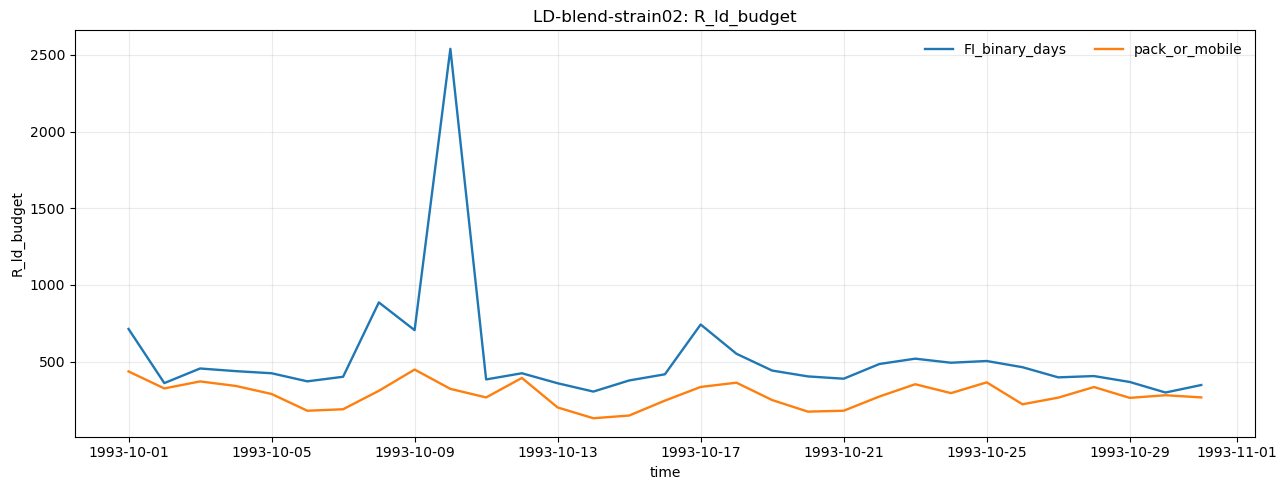

Saved: /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit/LD-blend-strain02/budget_timeseries_tau_ld_est_1993-10-01_1993-10-31.png


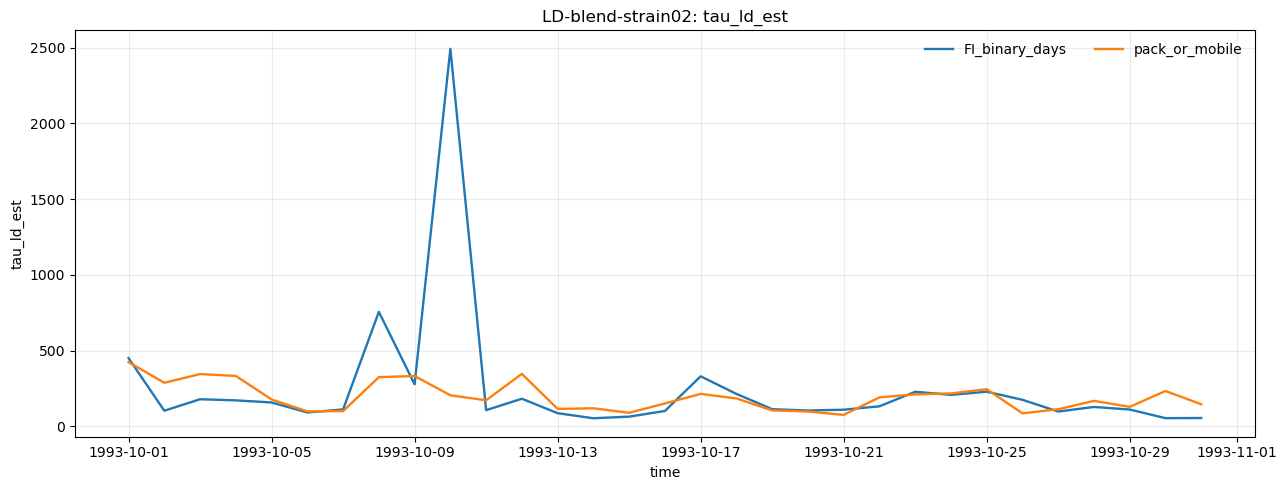

Saved: /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit/LD-blend-strain02/budget_timeseries_ld_mag_proxy_1993-10-01_1993-10-31.png


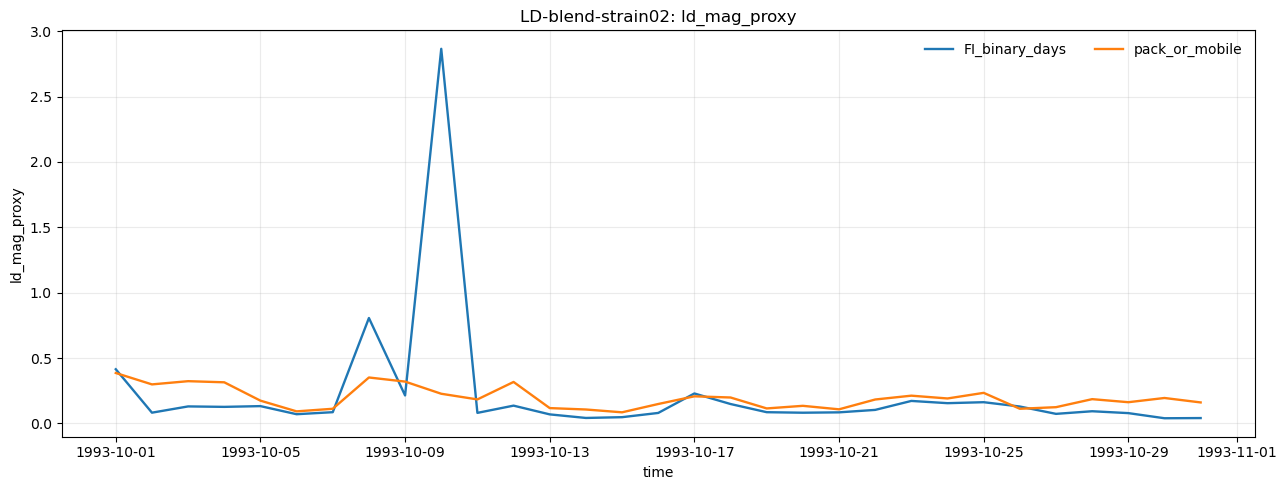

In [18]:
FORCE_BUDGET_SIM   = "LD-blend-strain02"
FORCE_BUDGET_START = DIAG_START
FORCE_BUDGET_END   = DIAG_END
cice_fb            = safe_load_cice(FORCE_BUDGET_SIM, FORCE_BUDGET_START, FORCE_BUDGET_END, variables=OUTCOME_DYN_VARS)
cls_fb             = safe_load_classified(FORCE_BUDGET_SIM, FORCE_BUDGET_START, FORCE_BUDGET_END, variables=["FI_mask"], method=METHOD)
cice_fb, cls_fb    = robust_align_time(cice_fb, cls_fb)
diag_fb            = compute_diagnostic_terms(cice_fb)
area_fb            = area_da(cice_fb)
fi_fb              = cls_fb["FI_mask"].astype(bool)
budget_vars        = [v for v in ["tau_air", "tau_ocean", "tau_internal", "tau_ld_est", "R_ld_budget", "P_ld_est", "ld_mag_proxy"] if v in diag_fb]
print("Available budget diagnostics:", budget_vars)
# Area-weighted time series over FI and mobile/pack zones.
rows = []
for zone, mask in {"FI_binary_days": fi_fb, "pack_or_mobile": ~fi_fb}.items():
    for v in budget_vars:
        ts              = area_weighted_mean(diag_fb[v], area_fb, mask)
        tmp             = ts.compute().to_series().reset_index()
        tmp.columns     = ["time", "value"]
        tmp["variable"] = v
        tmp["zone"]     = zone
        tmp["sim_name"] = FORCE_BUDGET_SIM
        rows.append(tmp)
BUDGET_TS = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
display_df(BUDGET_TS, n=20)
for v in ["R_ld_budget", "tau_ld_est", "ld_mag_proxy"]:
    if v in BUDGET_TS["variable"].unique():
        out = NOTEBOOK_FIG_ROOT / FORCE_BUDGET_SIM / f"budget_timeseries_{v}_{FORCE_BUDGET_START}_{FORCE_BUDGET_END}.png"
        plot_timeseries_df(BUDGET_TS[BUDGET_TS.variable == v], "time", "value", "zone", title=f"{FORCE_BUDGET_SIM}: {v}", ylabel=v, out=out)

In [ ]:
# Optional PyGMT maps for one date and one region.
# This uses shuga's CICEPlotter for projection/base layers and a lightweight scatter plotting path.
def quick_pygmt_map(da: xr.DataArray, sim_name: str, date: str, *,
                    region_name: str = REGION_NAME,
                    title: str | None = None,
                    cmap: str = "cmocean/amp",
                    series: Sequence[float] | None = None,
                    grid_style: str = "c0.12c",
                    out: Path | None = None):
    import pygmt
    run = make_run(sim_name, date, date)
    classify = make_classify()
    sp = CICEPlotter(run, classify)
    regions = sp._resolve_regions(region_name=region_name)
    reg = list(regions.values())[0]
    proj = sp.projection_from_region(reg, fig_size=15)
    coords = cice_fb[["TLON", "TLAT"]] if all(v in cice_fb for v in ["TLON", "TLAT"]) else sp._load_static_lonlat(sim_name=sim_name)
    field = da.sel(time=date, method="nearest") if "time" in da.dims else da
    data = sp.pygmt_da_prep(field, lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    fig = pygmt.Figure()
    with pygmt.config(MAP_FRAME_TYPE="plain", FONT="12p"):
        sp.pygmt_base_layer(fig, reg, proj, title=title or f"{sim_name}: {field.name}")
        if series is not None:
            pygmt.makecpt(cmap=cmap, series=list(series))
        else:
            pygmt.makecpt(cmap=cmap)
        fig.plot(x=data["lon"], y=data["lat"], style=grid_style, fill=data["z"], cmap=True, no_clip=True)
        fig.colorbar(position="JMB+w8c/0.4c+o0c/0.7c", frame=["af", f"x+l{field.name}"])
    if out is not None:
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, dpi=200)
        print(f"Saved: {out}")
    if SHOW_FIGS:
        fig.show()
    return fig
MAP_DATE = "1993-10-15"
for v, series in [("R_ld_budget", [0, 2]), ("tau_ld_est", [0, 20]), ("ld_mag_proxy", None)]:
    if v in diag_fb:
        out = NOTEBOOK_FIG_ROOT / FORCE_BUDGET_SIM / f"map_{v}_{REGION_NAME}_{MAP_DATE}.png" if SAVE_FIGS else None
        quick_pygmt_map(diag_fb[v], FORCE_BUDGET_SIM, MAP_DATE, region_name=REGION_NAME, title=f"{FORCE_BUDGET_SIM} {MAP_DATE}: {v}", series=series, out=out)


# 3. Diagnose the form function itself, not only its consequence

This section has two parts: (i) the analytical speed-space form-function sketch and (ii) diagnosed phase-space plots from the model output: `Ku proxy` versus ice speed, strain, relative ice-ocean speed, and binary-days FI/non-FI state.


Saved: /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit/analytical_form_function_comparison_corrected_blend_strain.png


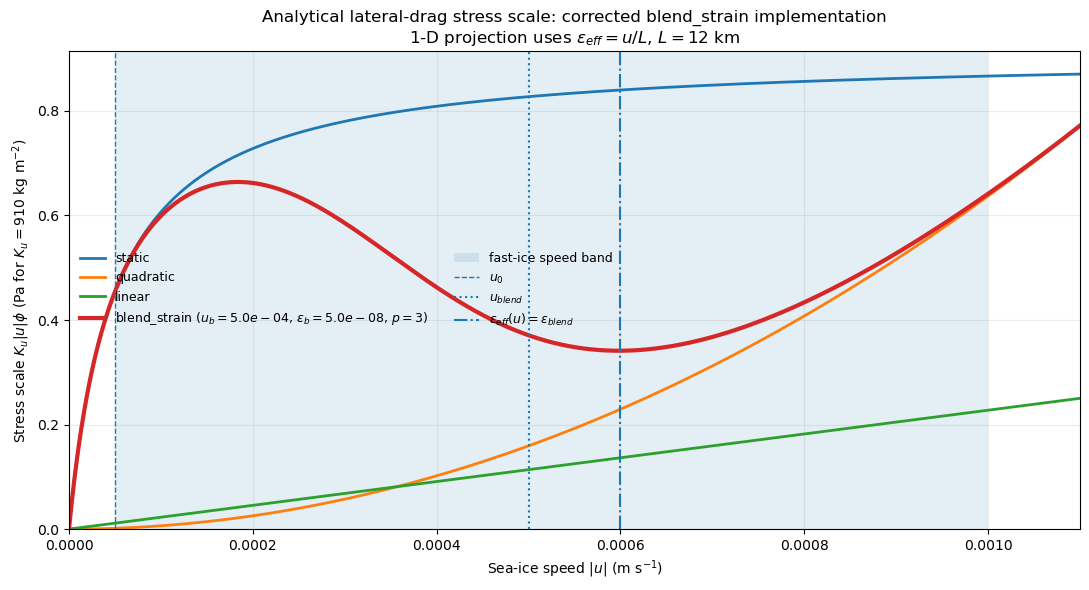

In [29]:
# Analytical lateral-drag form-function sketch matching the corrected CICE implementation
# in ice_dyn_shared.F90 stepu_C / stepv_C:
#
#   phi_static = Cs / (|u| + u0)
#   phi_quad   = Cq * |u|
#   phi_linear = C_L
#
#   w_eps  = 1 / (1 + (eps_eff / eps_blend)**blend_exp)
#   w_spd  = 1 / (1 + (|u| / u_blend)**blend_exp)
#   w_lock = w_eps * w_spd
#
#   phi_blend = w_lock * phi_static + (1 - w_lock) * phi_quad
#
#   tau_LD = -Ku * phi * u
#
# Because CICE blend_strain depends on both speed and strain rate, this 1-D
# analytical curve uses a plotting closure:
#
#   eps_eff(u) = u / L_eps_proxy
#
# where L_eps_proxy is a fixed deformation/anchoring length scale.
# ---------------------------------------------------------------------
# CICE-style scalar damping-rate functions
# ---------------------------------------------------------------------

def cice_phi_static(u, Cs, u0):
    return Cs / (u + u0)

def cice_phi_quad(u, Cq):
    return Cq * u

def cice_phi_linear(CL):
    return CL + np.zeros_like(u)

def cice_lock_weight_eps(eps_eff, eps_blend, blend_exp):
    eps_eff = np.maximum(eps_eff, 0.0)
    eb = max(eps_blend, 1.0e-20)
    r = eps_eff / eb
    return 1.0 / (1.0 + r**blend_exp)

def cice_lock_weight_speed(u, u_blend, blend_exp):
    ub = max(u_blend, 1.0e-20)
    r = np.maximum(u, 0.0) / ub
    return 1.0 / (1.0 + r**blend_exp)

def tau_static_scale(u, M_F2, Cs, u0):
    return M_F2 * u * cice_phi_static(u, Cs, u0)

def tau_quad_scale(u, M_F2, Cq):
    return M_F2 * u * cice_phi_quad(u, Cq)

def tau_linear_scale(u, M_F2, CL):
    return M_F2 * u * cice_phi_linear(CL)

def tau_blend_strain_scale(
    u,
    M_F2,
    Cs,
    Cq,
    u0,
    u_blend,
    eps_blend,
    blend_exp,
    L_eps_proxy,
):
    # 1-D plotting closure for strain rate.
    # This is not a CICE model assumption; it is only for the analytical sketch.
    eps_eff = u / L_eps_proxy

    w_eps = cice_lock_weight_eps(eps_eff, eps_blend, blend_exp)
    w_spd = cice_lock_weight_speed(u, u_blend, blend_exp)
    w_lock = w_eps * w_spd

    phi_static = cice_phi_static(u, Cs, u0)
    phi_quad = cice_phi_quad(u, Cq)

    phi_blend = w_lock * phi_static + (1.0 - w_lock) * phi_quad

    tau = M_F2 * u * phi_blend

    return tau, w_lock, w_eps, w_spd, eps_eff, phi_blend

# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------

u = np.linspace(0.0, 1.1e-3, 800)

# Representative mass/form-factor scale.
# In CICE this is Ku = velocity-grid ice/snow mass * F2.
# M_F2=910 kg m-2 is only a "1 m ice, F2=1" visual scale.
M_F2 = 910.0

params = dict(
    Cs=1.0e-3,
    Cq=700.0,
    CL=0.25,
    u0=5.0e-5,
)

blend = dict(
    Cs=1e-3,
    Cq=700.0,
    u0=5.0e-5,
    u_blend=5.0e-4,
    eps_blend=5.0e-8,
    blend_exp=3.0,
)

# Fixed plotting closure for eps_eff(u).
# 25 km gives eps_eff ~ 4e-8 s-1 at u=1e-3 m/s.
# 10 km gives eps_eff ~ 1e-7 s-1 at u=1e-3 m/s.
# Larger L_eps_proxy keeps the strain gate more permissive.
L_eps_proxy = 12.0e3  # metres

# ---------------------------------------------------------------------
# Compute curves
# ---------------------------------------------------------------------

tau_static = tau_static_scale(u, M_F2, params["Cs"], params["u0"])
tau_quad = tau_quad_scale(u, M_F2, params["Cq"])
tau_linear = tau_linear_scale(u, M_F2, params["CL"])

tau_blend, w_lock, w_eps, w_spd, eps_eff, phi_blend = tau_blend_strain_scale(
    u,
    M_F2=M_F2,
    Cs=blend["Cs"],
    Cq=blend["Cq"],
    u0=blend["u0"],
    u_blend=blend["u_blend"],
    eps_blend=blend["eps_blend"],
    blend_exp=blend["blend_exp"],
    L_eps_proxy=L_eps_proxy,
)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    u,
    tau_static,
    label="static",
    lw=2,
)

ax.plot(
    u,
    tau_quad,
    label="quadratic",
    lw=2,
)

ax.plot(
    u,
    tau_linear,
    label="linear",
    lw=2,
)

ax.plot(
    u,
    tau_blend,
    label=(
        "blend_strain "
        + rf"($u_b={blend['u_blend']:.1e}$, "
        + rf"$\epsilon_b={blend['eps_blend']:.1e}$, "
        + rf"$p={blend['blend_exp']:g}$)"
    ),
    lw=3,
)

ax.axvspan(params["u0"], 1.0e-3, alpha=0.12, label="fast-ice speed band")
ax.axvline(params["u0"], ls="--", lw=1, label="$u_0$")
ax.axvline(blend["u_blend"], ls=":", lw=1.5, label="$u_{blend}$")

# Mark where eps_eff(u) equals eps_blend under the plotting closure.
u_eps_transition = blend["eps_blend"] * L_eps_proxy
if u.min() <= u_eps_transition <= u.max():
    ax.axvline(
        u_eps_transition,
        ls="-.",
        lw=1.5,
        label=r"$\epsilon_{eff}(u)=\epsilon_{blend}$",
    )

ax.set_xlim(0.0, 1.1e-3)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("Sea-ice speed $|u|$ (m s$^{-1}$)")
ax.set_ylabel(r"Stress scale $K_u |u| \phi$ (Pa for $K_u=910$ kg m$^{-2}$)")
ax.set_title(
    "Analytical lateral-drag stress scale: corrected blend_strain implementation\n"
    + rf"1-D projection uses $\epsilon_{{eff}}=u/L$, $L={L_eps_proxy/1000:g}$ km"
)
ax.grid(alpha=0.25)
ax.legend(frameon=False, ncol=2, fontsize=9)

fig.tight_layout()

if SAVE_FIGS:
    out = NOTEBOOK_FIG_ROOT / "analytical_form_function_comparison_corrected_blend_strain.png"
    fig.savefig(out, dpi=180)
    print(f"Saved: {out}")

plt.show()

Saved: /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit/blend_strain_weight_cice_exact.png


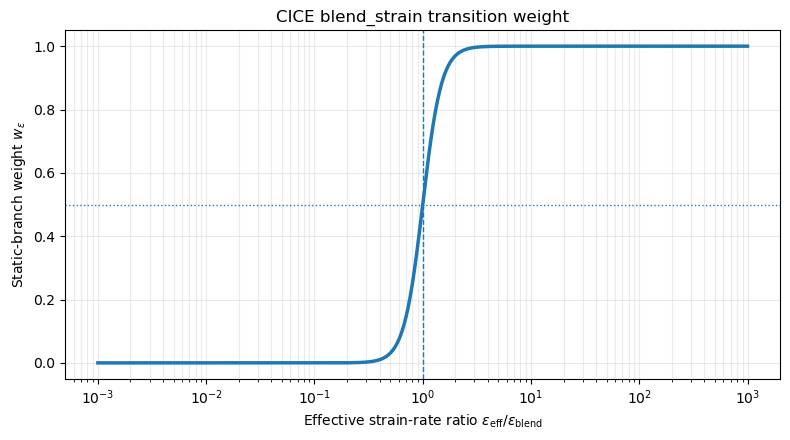

In [37]:
# Blend weight as implemented in CICE:
# low strain-rate  -> quadratic branch
# high strain-rate -> static branch

eps_ratio = np.logspace(-3, 3, 600)
eps_eff = eps_ratio * blend["eps_blend"]
w_eps = cice_blend_weight_eps(eps_eff, blend["eps_blend"], blend["blend_exp"])

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.semilogx(eps_ratio, w_eps, lw=2.5)
ax.axvline(1.0, ls="--", lw=1)
ax.axhline(0.5, ls=":", lw=1)

ax.set_xlabel(r"Effective strain-rate ratio $\epsilon_{\mathrm{eff}} / \epsilon_{\mathrm{blend}}$")
ax.set_ylabel(r"Static-branch weight $w_\epsilon$")
ax.set_title("CICE blend_strain transition weight")
ax.grid(alpha=0.25, which="both")

fig.tight_layout()

if SAVE_FIGS:
    out = NOTEBOOK_FIG_ROOT / "blend_strain_weight_cice_exact.png"
    fig.savefig(out, dpi=180)
    print(f"Saved: {out}")

plt.show()

,time,nj,ni,ld_mag_proxy,tau_ld_est,ice_speed,rel_ice_ocean_speed,strain_invariant,FI_class,TLON,TLAT,NLON,ELON,ELAT,ULAT,ULON,NLAT,FI_class_label
650924,1993-10-27,106,44,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mobile/pack
449490,1993-10-19,67,30,NaN,NaN,NaN,NaN,NaN,0,140.125000,9.580076,140.125000,140.250000,9.580032,9.703289,140.250000,9.703312,mobile/pack
440580,1993-10-19,17,120,0.0,0.0,0.108530,0.114399,3789.172852,0,320.125000,-66.715591,-39.875000,-39.750000,-66.715591,-66.662796,-39.750000,-66.662842,mobile/pack
730392,1993-10-31,7,132,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mobile/pack
683983,1993-10-29,19,163,0.0,0.0,0.106978,0.070160,3153.617432,0,46.125000,-65.026016,46.125000,46.250000,-65.025978,-64.973137,46.250000,-64.973190,mobile/pack
548635,1993-10-23,77,175,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mobile/pack
619233,1993-10-26,65,33,NaN,NaN,NaN,NaN,NaN,0,146.125000,5.616003,146.125000,146.250000,5.615977,5.740377,146.250000,5.740390,mobile/pack
418992,1993-10-18,32,132,0.0,0.0,0.000000,0.160834,NaN,0,344.125000,-51.559830,-15.875000,-15.750000,-51.559696,-51.481983,-15.750000,-51.482048,mobile/pack
147181,1993-10-07,7,121,0.0,0.0,0.131999,0.105100,14734.428711,0,322.125000,-75.163483,-37.875000,-37.750000,-75.163483,-75.110680,-37.750000,-75.110718,mobile/pack
126586,1993-10-06,28,46,0.0,0.0,0.000000,0.041717,NaN,0,172.125000,-56.265640,172.125000,172.250000,-56.265514,-56.196095,172.250000,-56.196159,mobile/pack


Saved: /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit/LD-static-Cs1e-3/phase_space_ld_mag_proxy_vs_ice_speed_1993-10-01_1993-10-31.png


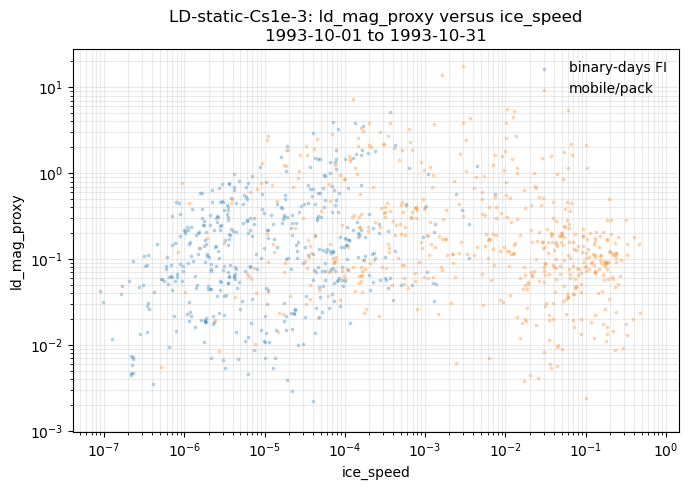

Saved: /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit/LD-static-Cs1e-3/phase_space_ld_mag_proxy_vs_strain_invariant_1993-10-01_1993-10-31.png


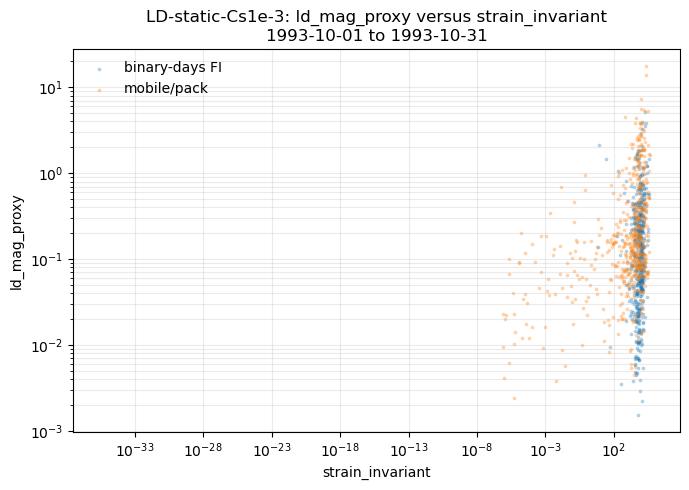

Saved: /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit/LD-static-Cs1e-3/phase_space_ld_mag_proxy_vs_rel_ice_ocean_speed_1993-10-01_1993-10-31.png


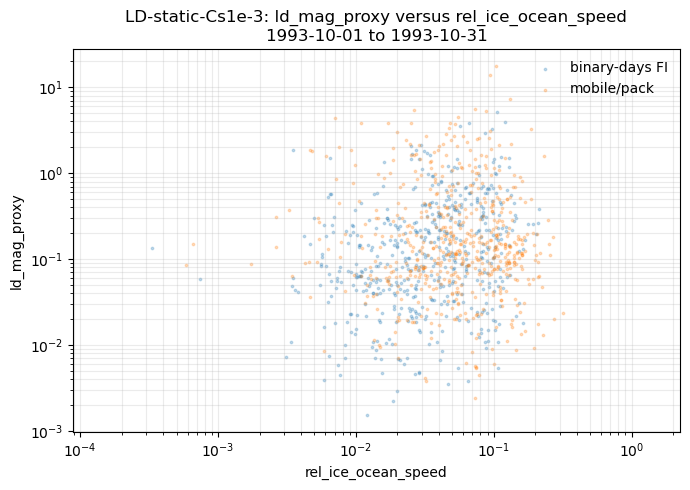

Saved: /g/data/gv90/da1339/GRAPHICAL/lateral_drag_process_audit/LD-static-Cs1e-3/phase_space_tau_ld_est_vs_strain_invariant_1993-10-01_1993-10-31.png


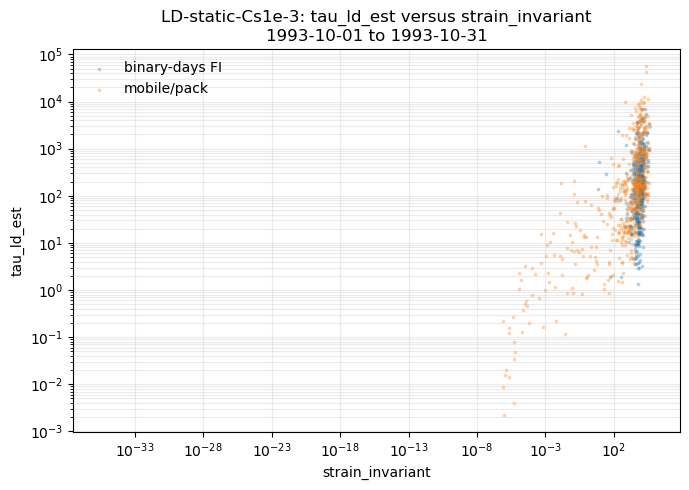

In [7]:
PHASE_SIM       = "LD-static-Cs1e-3"
PHASE_START     = DIAG_START
PHASE_END       = DIAG_END
cice_ph         = safe_load_cice(PHASE_SIM, PHASE_START, PHASE_END, variables=OUTCOME_DYN_VARS)
cls_ph          = safe_load_classified(PHASE_SIM, PHASE_START, PHASE_END, variables=["FI_mask"], method=METHOD)
cice_ph, cls_ph = robust_align_time(cice_ph, cls_ph)
diag_ph         = compute_diagnostic_terms(cice_ph)
phase             = xr.merge([diag_ph, cls_ph[["FI_mask"]]], compat="override")
phase["FI_class"] = xr.where(phase["FI_mask"].astype(bool), 1, 0)
phase_vars        = ["ld_mag_proxy", "tau_ld_est", "ice_speed", "rel_ice_ocean_speed", "strain_invariant", "R_ld_budget", "FI_class"]
PHASE_DF                   = sample_points_for_phase_space(phase, phase_vars, sample_frac=SAMPLE_FRAC)
PHASE_DF["FI_class_label"] = np.where(PHASE_DF.get("FI_class", 0).astype(float) > 0.5, "binary-days FI", "mobile/pack")
display_df(PHASE_DF, n=20)
pairs = [
    ("ice_speed", "ld_mag_proxy"),
    ("strain_invariant", "ld_mag_proxy"),
    ("rel_ice_ocean_speed", "ld_mag_proxy"),
    ("strain_invariant", "tau_ld_est"),
]
for x, y in pairs:
    if x not in PHASE_DF or y not in PHASE_DF:
        continue
    fig, ax = plt.subplots(figsize=(7, 5))
    for label, part in PHASE_DF.dropna(subset=[x, y]).groupby("FI_class_label"):
        ax.scatter(part[x], part[y], s=3, alpha=0.25, label=label)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{PHASE_SIM}: {y} versus {x}\n{PHASE_START} to {PHASE_END}")
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)
    fig.tight_layout()
    if SAVE_FIGS:
        out = NOTEBOOK_FIG_ROOT / PHASE_SIM / f"phase_space_{y}_vs_{x}_{PHASE_START}_{PHASE_END}.png"
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, dpi=180)
        print(f"Saved: {out}")
    plt.show()


# 4. Analyse formation, retention, and breakout separately

Instead of one annual FIA score, this section decomposes each experiment into formation, retention, and breakout diagnostics: first persistent classification date, maximum persistence, last classified date, growth-rate windows, retreat-rate windows, and region-aware summaries where available.


In [ ]:
def daily_fia_from_mask(sim_name: str, start: str, end: str) -> xr.DataArray:
    cice = safe_load_cice(sim_name, start, end, variables=["tarea", "TLON", "TLAT"])
    cls = safe_load_classified(sim_name, start, end, variables=["FI_mask"], method=METHOD)
    cice, cls = robust_align_time(cice, cls)
    fia = area_sum(cls["FI_mask"].astype(bool), area_da(cice)) / 1e9
    return fia.rename("FIA")


def formation_retention_breakout_metrics(sim_name: str, start: str = COMMON_START, end: str = COMMON_END) -> dict:
    fia = daily_fia_from_mask(sim_name, start, end).compute()
    s = fia.to_series()
    active = s > 1.0  # 10^3 km2 threshold to avoid all-zero numerical edge effects
    out = {"sim_name": sim_name, "start": start, "end": end}
    out["mean_FIA"] = float(s.mean())
    out["max_FIA"] = float(s.max())
    out["min_FIA"] = float(s.min())
    out["date_max_FIA"] = s.idxmax().strftime("%Y-%m-%d") if len(s) else None
    out["date_min_FIA"] = s.idxmin().strftime("%Y-%m-%d") if len(s) else None
    out["first_active_date"] = active[active].index.min().strftime("%Y-%m-%d") if active.any() else None
    out["last_active_date"] = active[active].index.max().strftime("%Y-%m-%d") if active.any() else None

    def slope_window(t0, t1):
        sub = s.loc[pd.Timestamp(t0):pd.Timestamp(t1)].dropna()
        if len(sub) < 5:
            return np.nan
        x = (sub.index - sub.index[0]).days.values.astype(float)
        return float(np.polyfit(x, sub.values, 1)[0])  # 10^3 km2 per day

    out["growth_rate_AprAug_10^3_km2_day-1"] = slope_window(FORMATION_START, FORMATION_END)
    out["retreat_rate_NovDec_10^3_km2_day-1"] = slope_window(RETREAT_START, RETREAT_END)
    return out

FRB_ROWS = []
for sim in CORE_SIMS:
    try:
        FRB_ROWS.append(formation_retention_breakout_metrics(sim, COMMON_START, COMMON_END))
    except Exception as exc:
        print(f"Skipping {sim}: {exc}")
FRB = pd.DataFrame(FRB_ROWS)
display_df(FRB, n=50)
FRB.to_csv(NOTEBOOK_FIG_ROOT / "formation_retention_breakout_common_window.csv", index=False)


In [ ]:
# Plot daily FIA from classification masks for the selected core sims.
FIA_ROWS = []
for sim in CORE_SIMS:
    try:
        fia = daily_fia_from_mask(sim, COMMON_START, COMMON_END).compute().to_series().reset_index()
        fia.columns = ["time", "FIA_10^3_km2"]
        fia["sim_name"] = sim
        FIA_ROWS.append(fia)
    except Exception as exc:
        print(f"Skipping {sim}: {exc}")
FIA_DF = pd.concat(FIA_ROWS, ignore_index=True) if FIA_ROWS else pd.DataFrame()
if len(FIA_DF):
    plot_timeseries_df(
        FIA_DF, "time", "FIA_10^3_km2", "sim_name",
        title=f"Binary-days FIA: {COMMON_START} to {COMMON_END}",
        ylabel="FIA (10$^3$ km$^2$)",
        out=NOTEBOOK_FIG_ROOT / f"fia_binary_days_{COMMON_START}_{COMMON_END}.png",
    )


# 5. Do paired anomaly analysis relative to no-drag / static / quadratic baselines

Pairwise anomalies reveal where a form function actually changes the solution. This section computes time-mean anomaly maps and area-weighted anomaly summaries for speed, strain, FIP, stress terms, and lateral-drag proxies.


In [ ]:
BASELINE_SIM = "LD-quad-Cq700"
TARGET_SIM = "LD-blend-strain04"
ANOM_START = DIAG_START
ANOM_END = DIAG_END

ANOM_VARS = OUTCOME_DYN_VARS
base = safe_load_cice(BASELINE_SIM, ANOM_START, ANOM_END, variables=ANOM_VARS)
targ = safe_load_cice(TARGET_SIM, ANOM_START, ANOM_END, variables=ANOM_VARS)
base_cls = safe_load_classified(BASELINE_SIM, ANOM_START, ANOM_END, variables=["FI_mask"], method=METHOD)
targ_cls = safe_load_classified(TARGET_SIM, ANOM_START, ANOM_END, variables=["FI_mask"], method=METHOD)
base, targ, base_cls, targ_cls = robust_align_time(base, targ, base_cls, targ_cls)

base_diag = compute_diagnostic_terms(base)
targ_diag = compute_diagnostic_terms(targ)
base_diag, targ_diag = robust_align_time(base_diag, targ_diag)

ANOM = xr.Dataset()
for v in sorted(set(base_diag.data_vars).intersection(targ_diag.data_vars)):
    ANOM[f"d_{v}"] = (targ_diag[v] - base_diag[v]).rename(f"d_{v}")

ANOM["d_FI_mask"] = (targ_cls["FI_mask"].astype("int8") - base_cls["FI_mask"].astype("int8")).rename("d_FI_mask")
ANOM["d_FIP"] = (compute_fip(targ_cls["FI_mask"]) - compute_fip(base_cls["FI_mask"])).rename("d_FIP")

area_anom = area_da(targ)
rows = []
for v in ANOM.data_vars:
    da = ANOM[v]
    if "time" in da.dims:
        da_mean = da.mean("time", skipna=True)
    else:
        da_mean = da
    rows.append({
        "target_minus_baseline": f"{TARGET_SIM} - {BASELINE_SIM}",
        "variable": v,
        "area_weighted_mean_anomaly": float(area_weighted_mean(da_mean, area_anom).compute()),
        "p05": float(da_mean.quantile(0.05).compute()),
        "p50": float(da_mean.quantile(0.50).compute()),
        "p95": float(da_mean.quantile(0.95).compute()),
    })
ANOM_SUMMARY = pd.DataFrame(rows)
display_df(ANOM_SUMMARY, n=100)
ANOM_SUMMARY.to_csv(NOTEBOOK_FIG_ROOT / f"anomaly_summary_{TARGET_SIM}_minus_{BASELINE_SIM}_{ANOM_START}_{ANOM_END}.csv", index=False)


In [ ]:
# Optional maps of paired anomalies.
for v, series, cmap in [
    ("d_ice_speed", [-0.01, 0.01], "polar"),
    ("d_strain_invariant", None, "polar"),
    ("d_tau_ld_est", None, "polar"),
    ("d_FIP", [-1, 1], "polar"),
]:
    if v not in ANOM:
        continue
    da_map = ANOM[v].mean("time", skipna=True) if "time" in ANOM[v].dims else ANOM[v]
    out = NOTEBOOK_FIG_ROOT / f"map_{TARGET_SIM}_minus_{BASELINE_SIM}_{v}_{REGION_NAME}_{ANOM_START}_{ANOM_END}.png" if SAVE_FIGS else None
    try:
        quick_pygmt_map(da_map, TARGET_SIM, ANOM_START, region_name=REGION_NAME, title=f"{TARGET_SIM} - {BASELINE_SIM}: {v}", cmap=cmap, series=series, out=out)
    except Exception as exc:
        print(f"Map failed for {v}: {exc}")


# 6. Bring in spatial skill, not just total FIA

This section computes hit/miss/false-alarm style diagnostics against AF2020 gridded fast-ice observations where available through `SeaIceObservations.load_af2020_regridded()`. This is the critical test for whether extra FIA is useful recall or false-alarm area.


In [ ]:
def load_af2020_mask(start: str, end: str, reference_run: RunSpec | None = None) -> xr.DataArray:
    """Load AF2020 regridded fast-ice mask on the model grid. Returns bool mask over time where possible."""
    run = reference_run or make_run(CORE_SIMS[0], start, end)
    obs = SeaIceObservations(run)
    ds = obs.load_af2020_regridded()
    var_name = obs.observations.af2020_regridded_var
    if var_name not in ds:
        # fallback: use the first non-coordinate variable
        var_name = next(iter(ds.data_vars))
    da = ds[var_name]
    time_var = getattr(obs.observations, "af2020_time_var", None)
    if time_var and time_var in da.dims and time_var != "time":
        da = da.rename({time_var: "time"})
    if "time" in da.dims:
        da = da.sel(time=slice(start, end))
    return (da > 0).rename("AF2020_mask")


def binary_spatial_skill(model_mask: xr.DataArray, obs_mask: xr.DataArray, area: xr.DataArray) -> pd.DataFrame:
    model_mask, obs_mask = xr.align(model_mask.astype(bool), obs_mask.astype(bool), join="inner")
    area2 = area
    hit = model_mask & obs_mask
    miss = (~model_mask) & obs_mask
    false = model_mask & (~obs_mask)
    correct_reject = (~model_mask) & (~obs_mask)

    hit_a = area_sum(hit, area2) / 1e9
    miss_a = area_sum(miss, area2) / 1e9
    false_a = area_sum(false, area2) / 1e9
    cr_a = area_sum(correct_reject, area2) / 1e9

    precision = hit_a / (hit_a + false_a + EPS)
    recall = hit_a / (hit_a + miss_a + EPS)
    f1 = 2 * precision * recall / (precision + recall + EPS)
    jaccard = hit_a / (hit_a + miss_a + false_a + EPS)
    far = false_a / (hit_a + false_a + EPS)

    ds = xr.Dataset({
        "hit_area": hit_a,
        "miss_area": miss_a,
        "false_alarm_area": false_a,
        "correct_reject_area": cr_a,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "Jaccard": jaccard,
        "false_alarm_ratio": far,
    })
    return ds.to_dataframe().reset_index()

SPATIAL_SKILL_ROWS = []
try:
    obs_mask = load_af2020_mask(COMMON_START, COMMON_END, make_run(CORE_SIMS[0], COMMON_START, COMMON_END))
    for sim in CORE_SIMS:
        cice = safe_load_cice(sim, COMMON_START, COMMON_END, variables=["tarea", "TLON", "TLAT"])
        cls = safe_load_classified(sim, COMMON_START, COMMON_END, variables=["FI_mask"], method=METHOD)
        cice, cls = robust_align_time(cice, cls)
        skill = binary_spatial_skill(cls["FI_mask"], obs_mask, area_da(cice))
        skill["sim_name"] = sim
        SPATIAL_SKILL_ROWS.append(skill)
    SPATIAL_SKILL = pd.concat(SPATIAL_SKILL_ROWS, ignore_index=True)
    display_df(SPATIAL_SKILL, n=20)
    SPATIAL_SKILL.to_csv(NOTEBOOK_FIG_ROOT / "spatial_skill_daily_against_AF2020.csv", index=False)
except Exception as exc:
    print(f"AF2020 spatial skill unavailable: {exc}")
    SPATIAL_SKILL = pd.DataFrame()


In [ ]:
if len(SPATIAL_SKILL):
    # Mean skill over time.
    mean_skill = SPATIAL_SKILL.groupby("sim_name")[["precision", "recall", "F1", "Jaccard", "false_alarm_ratio", "hit_area", "miss_area", "false_alarm_area"]].mean().reset_index()
    display_df(mean_skill, n=50)
    mean_skill.to_csv(NOTEBOOK_FIG_ROOT / "spatial_skill_mean_against_AF2020.csv", index=False)

    for metric in ["F1", "Jaccard", "false_alarm_ratio"]:
        plot_timeseries_df(
            SPATIAL_SKILL, "time", metric, "sim_name",
            title=f"Daily spatial skill against AF2020: {metric}",
            ylabel=metric,
            out=NOTEBOOK_FIG_ROOT / f"spatial_skill_{metric}_{COMMON_START}_{COMMON_END}.png",
        )


# 7. Use distance-to-boundary diagnostics

Because lateral drag is a boundary/geometric parameterisation, diagnose how much fast ice and how much lateral-drag activity occurs as a function of distance from the coastline / grounded-iceberg anchor proxy. This section uses `F2E/F2N` when present and falls back to the external form-factor file.


In [ ]:
def anchor_mask_from_f2(ds: xr.Dataset, form_factor_file: Path = FORM_FACTOR_FILE) -> xr.DataArray:
    """Return a T-grid-ish anchor mask from F2E/F2N or external F2x/F2y."""
    if "F2E" in ds or "F2N" in ds:
        arrs = []
        if "F2E" in ds:
            arrs.append(abs(ds["F2E"].isel(time=0, drop=True)) if "time" in ds["F2E"].dims else abs(ds["F2E"]))
        if "F2N" in ds:
            arrs.append(abs(ds["F2N"].isel(time=0, drop=True)) if "time" in ds["F2N"].dims else abs(ds["F2N"]))
        f2mag = xr.concat(arrs, dim="edge").max("edge")
        return (f2mag > 0).rename("anchor_mask")
    if form_factor_file.exists():
        ff = xr.open_dataset(form_factor_file)
        if all(v in ff for v in ["F2x", "F2y"]):
            f2mag = xr.apply_ufunc(np.hypot, ff["F2x"], ff["F2y"], dask="allowed")
            # assume same ni/nj shape as CICE grid
            f2mag = f2mag.rename({d: nd for d, nd in zip(f2mag.dims, area_da(ds).dims)}) if f2mag.dims != area_da(ds).dims else f2mag
            return (f2mag > 0).rename("anchor_mask")
    raise FileNotFoundError("No F2E/F2N fields and external form-factor file unavailable.")


def distance_from_anchor_km(anchor: xr.DataArray, area: xr.DataArray) -> xr.DataArray:
    try:
        from scipy.ndimage import distance_transform_edt
    except Exception as exc:
        raise ImportError("scipy is required for distance_transform_edt") from exc
    # This is a grid-distance approximation using median cell size. Good enough for binning diagnostics.
    cell_km = float(np.sqrt(area.median().compute()) / 1000.0)
    dist = distance_transform_edt((~anchor.fillna(False)).values, sampling=cell_km)
    return xr.DataArray(dist, dims=anchor.dims, coords=anchor.coords, name="distance_to_anchor_km")


def distance_bin_summary(sim_name: str, start: str, end: str, bins_km: Sequence[float] = (0, 25, 50, 100, 200, 400, 1000)) -> pd.DataFrame:
    vars_ = list(dict.fromkeys(OUTCOME_DYN_VARS + ["tarea", "TLON", "TLAT"]))
    cice = safe_load_cice(sim_name, start, end, variables=vars_)
    cls = safe_load_classified(sim_name, start, end, variables=["FI_mask"], method=METHOD)
    cice, cls = robust_align_time(cice, cls)
    area = area_da(cice)
    diag = compute_diagnostic_terms(cice)
    anchor = anchor_mask_from_f2(cice)
    dist = distance_from_anchor_km(anchor, area)
    fi = cls["FI_mask"].astype(bool)

    rows = []
    for lo, hi in zip(bins_km[:-1], bins_km[1:]):
        bmask = (dist >= lo) & (dist < hi)
        row = {"sim_name": sim_name, "bin_km": f"{lo:g}-{hi:g}", "bin_lo_km": lo, "bin_hi_km": hi}
        row["mean_FIA_10^3_km2"] = float((area_sum(fi.where(bmask), area) / 1e9).mean("time").compute())
        if "tau_ld_est" in diag:
            row["mean_tau_ld_est"] = float(area_weighted_mean(diag["tau_ld_est"], area, bmask).mean("time").compute())
        if "ld_mag_proxy" in diag:
            row["mean_ld_mag_proxy"] = float(area_weighted_mean(diag["ld_mag_proxy"], area, bmask).mean("time").compute())
        if "ice_speed" in diag:
            row["mean_speed"] = float(area_weighted_mean(diag["ice_speed"], area, bmask).mean("time").compute())
        rows.append(row)
    return pd.DataFrame(rows)

DIST_ROWS = []
for sim in CORE_SIMS:
    try:
        DIST_ROWS.append(distance_bin_summary(sim, DIAG_START, DIAG_END))
    except Exception as exc:
        print(f"Skipping distance-bin summary for {sim}: {exc}")
DIST_SUMMARY = pd.concat(DIST_ROWS, ignore_index=True) if DIST_ROWS else pd.DataFrame()
display_df(DIST_SUMMARY, n=100)
DIST_SUMMARY.to_csv(NOTEBOOK_FIG_ROOT / f"distance_to_anchor_summary_{DIAG_START}_{DIAG_END}.csv", index=False)


In [ ]:
if len(DIST_SUMMARY):
    for metric in [c for c in ["mean_FIA_10^3_km2", "mean_tau_ld_est", "mean_ld_mag_proxy", "mean_speed"] if c in DIST_SUMMARY.columns]:
        fig, ax = plt.subplots(figsize=(10, 5))
        for sim, part in DIST_SUMMARY.groupby("sim_name"):
            ax.plot(part["bin_hi_km"], part[metric], marker="o", label=sim)
        ax.set_xscale("log")
        ax.set_xlabel("Distance-to-anchor bin upper edge (km)")
        ax.set_ylabel(metric)
        ax.set_title(f"Distance-to-anchor diagnostic: {metric}\n{DIAG_START} to {DIAG_END}")
        ax.grid(alpha=0.25, which="both")
        ax.legend(frameon=False, fontsize=8)
        fig.tight_layout()
        if SAVE_FIGS:
            out = NOTEBOOK_FIG_ROOT / f"distance_to_anchor_{metric}_{DIAG_START}_{DIAG_END}.png"
            fig.savefig(out, dpi=180)
            print(f"Saved: {out}")
        plt.show()


# 8. Check whether 1993 is a valid evaluation year

The common 1993 window is useful for comparing short blend-strain experiments, but January–March may be dominated by initial-condition/spin-up behaviour. This section quantifies how rankings change when early 1993 is excluded and, for long experiments, when later years are used.


In [ ]:
def fia_skill_against_af2020_clim(sim_name: str, start: str, end: str) -> dict:
    fia = daily_fia_from_mask(sim_name, start, end).compute()
    obs = SeaIceObservations(make_run(sim_name, start, end)).repeat_af2020_fia_daily_climatology(start, end).compute()
    fia, obs = xr.align(fia, obs, join="inner")
    diff = fia - obs
    return {
        "sim_name": sim_name,
        "start": start,
        "end": end,
        "n_days": int(fia.sizes.get("time", 0)),
        "bias_10^3_km2": float(diff.mean().values),
        "rmse_10^3_km2": float(np.sqrt((diff**2).mean()).values),
        "corr": float(xr.corr(fia, obs, dim="time").values),
        "model_max_doy": int(pd.Timestamp(fia.time.values[int(fia.argmax("time"))]).dayofyear),
        "obs_max_doy": int(pd.Timestamp(obs.time.values[int(obs.argmax("time"))]).dayofyear),
    }

WINDOWS = [
    ("full_1993", "1993-01-01", "1993-12-31"),
    ("post_spinup_1993", "1993-04-01", "1993-12-31"),
    ("formation_retention_1993", "1993-04-01", "1993-10-31"),
]
SPINUP_ROWS = []
for label, start, end in WINDOWS:
    for sim in CORE_SIMS:
        try:
            row = fia_skill_against_af2020_clim(sim, start, end)
            row["window"] = label
            SPINUP_ROWS.append(row)
        except Exception as exc:
            print(f"Skipping {sim} {label}: {exc}")
SPINUP_SKILL = pd.DataFrame(SPINUP_ROWS)
display_df(SPINUP_SKILL.sort_values(["window", "rmse_10^3_km2"]), n=100)
SPINUP_SKILL.to_csv(NOTEBOOK_FIG_ROOT / "spinup_window_fia_skill_against_AF2020_climatology.csv", index=False)


In [ ]:
# Longer-window comparison for experiments that actually have long enough output.
LONG_WINDOW_SIMS = ["LD-static-Cs1e-3", "LD-static-Cs5e-4", "LD-quad-Cq700", "LD-quad-Cq70", "LD-linear-CL0p25"]
LONG_START = "1994-01-01"
LONG_END = "2003-12-31"
LONG_ROWS = []
for sim in LONG_WINDOW_SIMS:
    groups = list_month_groups(sim)
    if not groups or groups[0] > LONG_START[:7] or groups[-1] < LONG_END[:7]:
        print(f"Skipping {sim}; available {groups[0] if groups else None} to {groups[-1] if groups else None}")
        continue
    try:
        LONG_ROWS.append(fia_skill_against_af2020_clim(sim, LONG_START, LONG_END))
    except Exception as exc:
        print(f"Skipping {sim}: {exc}")
LONG_SKILL = pd.DataFrame(LONG_ROWS)
display_df(LONG_SKILL.sort_values("rmse_10^3_km2") if len(LONG_SKILL) else LONG_SKILL, n=50)
LONG_SKILL.to_csv(NOTEBOOK_FIG_ROOT / f"long_window_fia_skill_{LONG_START}_{LONG_END}.csv", index=False)


# 9. Minimum extra CICE outputs to request next

This section audits current history output against the diagnostics we actually need. It identifies what can be computed now and what should be added as explicit CICE history variables for the next lateral-drag experiment cycle.


In [ ]:
REQUIRED_DIAGNOSTIC_VARS = {
    "outcome_core": ["aice", "hi", "uvel", "vvel", "tarea", "TLON", "TLAT"],
    "classification_context": ["uvel", "vvel", "aice", "hi"],
    "forcing": ["uocn", "vocn", "uatm", "vatm"],
    "strain": ["divu", "shear", "sig1", "sig2", "sigP"],
    "stress_budget": ["strairx", "strairy", "strocnx", "strocny", "strintx", "strinty", "strcorx", "strcory", "strtltx", "strtlty"],
    "lateral_drag_available_proxy": ["KuxE", "KuxN", "KuyE", "KuyN", "F2E", "F2N"],
    "lateral_drag_should_add": [
        "tau_ld_x", "tau_ld_y", "tau_ld_mag", "Ku_ld", "blend_weight", "strain_used_by_blend",
        "mobile_branch_weight", "static_branch_weight", "u_rel_used_by_ld", "distance_to_anchor", "ld_power",
    ],
}

def diagnostic_availability_matrix(sims: Sequence[str], group: str = "1993-10") -> pd.DataFrame:
    rows = []
    for sim in sims:
        vars_ = set(list_group_variables(sim, group=group))
        for category, required in REQUIRED_DIAGNOSTIC_VARS.items():
            present = [v for v in required if v in vars_]
            missing = [v for v in required if v not in vars_]
            rows.append({
                "sim_name": sim,
                "group": group,
                "category": category,
                "n_required": len(required),
                "n_present": len(present),
                "present": ", ".join(present),
                "missing": ", ".join(missing),
            })
    return pd.DataFrame(rows)

AVAIL = diagnostic_availability_matrix(ALL_CANDIDATE_SIMS, group="1993-10")
display_df(AVAIL, n=200)
AVAIL.to_csv(NOTEBOOK_FIG_ROOT / "diagnostic_variable_availability_1993-10.csv", index=False)

print("\nRecommended explicit history additions for the next CICE lateral-drag runs:")
for v in REQUIRED_DIAGNOSTIC_VARS["lateral_drag_should_add"]:
    print(f"  - {v}")


# 10. Build a better performance scorecard

The scorecard combines outcome skill, spatial skill, dynamic plausibility, and collateral-damage indicators. It is intentionally transparent: each column is a diagnostic, not a hidden aggregate score. Add or remove columns depending on the final paper narrative.


In [ ]:
def dynamic_plausibility_row(sim_name: str, start: str, end: str) -> dict:
    cice = safe_load_cice(sim_name, start, end, variables=OUTCOME_DYN_VARS)
    cls = safe_load_classified(sim_name, start, end, variables=["FI_mask"], method=METHOD)
    cice, cls = robust_align_time(cice, cls)
    area = area_da(cice)
    fi = cls["FI_mask"].astype(bool)
    pack = ~fi
    diag = compute_diagnostic_terms(cice)
    row = {"sim_name": sim_name, "start": start, "end": end}
    if "ice_speed" in diag:
        row["FI_mean_speed"] = float(area_weighted_mean(diag["ice_speed"], area, fi).mean("time").compute())
        row["pack_mean_speed"] = float(area_weighted_mean(diag["ice_speed"], area, pack).mean("time").compute())
    if "strain_invariant" in diag:
        row["FI_mean_strain"] = float(area_weighted_mean(diag["strain_invariant"], area, fi).mean("time").compute())
        row["pack_mean_strain"] = float(area_weighted_mean(diag["strain_invariant"], area, pack).mean("time").compute())
    if "R_ld_budget" in diag:
        row["FI_mean_R_ld_budget"] = float(area_weighted_mean(diag["R_ld_budget"], area, fi).mean("time").compute())
        row["pack_mean_R_ld_budget"] = float(area_weighted_mean(diag["R_ld_budget"], area, pack).mean("time").compute())
    if "P_ld_est" in diag:
        row["FI_mean_P_ld_est"] = float(area_weighted_mean(diag["P_ld_est"], area, fi).mean("time").compute())
    return row

SCORE_ROWS = []
for sim in CORE_SIMS:
    try:
        fia_skill = fia_skill_against_af2020_clim(sim, COMMON_START, COMMON_END)
    except Exception as exc:
        print(f"FIA skill unavailable for {sim}: {exc}")
        fia_skill = {"sim_name": sim}
    try:
        dyn = dynamic_plausibility_row(sim, DIAG_START, DIAG_END)
    except Exception as exc:
        print(f"Dynamic diagnostics unavailable for {sim}: {exc}")
        dyn = {"sim_name": sim}
    row = {**fia_skill, **{k: v for k, v in dyn.items() if k != "sim_name"}}
    if len(SPATIAL_SKILL):
        m = SPATIAL_SKILL[SPATIAL_SKILL.sim_name == sim][["precision", "recall", "F1", "Jaccard", "false_alarm_ratio"]].mean().to_dict()
        row.update({f"spatial_{k}": v for k, v in m.items()})
    SCORE_ROWS.append(row)

SCORECARD = pd.DataFrame(SCORE_ROWS)
# A convenience rank by FIA RMSE only. Do not treat this as the final ranking.
if "rmse_10^3_km2" in SCORECARD:
    SCORECARD["rank_by_FIA_RMSE_only"] = SCORECARD["rmse_10^3_km2"].rank(method="min")
display_df(SCORECARD.sort_values("rank_by_FIA_RMSE_only") if "rank_by_FIA_RMSE_only" in SCORECARD else SCORECARD, n=50)
SCORECARD.to_csv(NOTEBOOK_FIG_ROOT / f"lateral_drag_scorecard_{COMMON_START}_{COMMON_END}.csv", index=False)


# 11. What the current FIA plot suggests, quantified

This section reproduces the headline FIA comparison and converts the visual impression into simple quantitative statements: bias, timing error, amplitude error, and late-season retention bias.


In [ ]:
def fia_obs_climatology(start: str, end: str, sim_name: str = CORE_SIMS[0]) -> xr.DataArray:
    return SeaIceObservations(make_run(sim_name, start, end)).repeat_af2020_fia_daily_climatology(start, end)

# Build a combined FIA dataframe with AF2020 climatology.
rows = []
obs = fia_obs_climatology(COMMON_START, COMMON_END).compute().to_series().reset_index()
obs.columns = ["time", "FIA_10^3_km2"]
obs["sim_name"] = "AF2020_climatology"
rows.append(obs)
for sim in CORE_SIMS:
    try:
        fia = daily_fia_from_mask(sim, COMMON_START, COMMON_END).compute().to_series().reset_index()
        fia.columns = ["time", "FIA_10^3_km2"]
        fia["sim_name"] = sim
        rows.append(fia)
    except Exception as exc:
        print(f"Skipping {sim}: {exc}")
FIA_WITH_OBS = pd.concat(rows, ignore_index=True)

plot_timeseries_df(
    FIA_WITH_OBS, "time", "FIA_10^3_km2", "sim_name",
    title="Current lateral-drag FIA comparison with AF2020 climatology",
    ylabel="FIA (10$^3$ km$^2$)",
    out=NOTEBOOK_FIG_ROOT / f"current_FIA_plot_quantified_{COMMON_START}_{COMMON_END}.png",
)

# Quantified interpretation table.
obs_s = FIA_WITH_OBS[FIA_WITH_OBS.sim_name == "AF2020_climatology"].set_index("time")["FIA_10^3_km2"]
interp_rows = []
for sim, part in FIA_WITH_OBS[FIA_WITH_OBS.sim_name != "AF2020_climatology"].groupby("sim_name"):
    s = part.set_index("time")["FIA_10^3_km2"].reindex(obs_s.index)
    diff = s - obs_s
    late = diff.loc[pd.Timestamp("1993-09-01"):pd.Timestamp("1993-12-31")]
    interp_rows.append({
        "sim_name": sim,
        "annual_bias": float(diff.mean()),
        "annual_rmse": float(np.sqrt((diff**2).mean())),
        "late_season_bias_SepDec": float(late.mean()),
        "model_max_FIA": float(s.max()),
        "obs_max_FIA": float(obs_s.max()),
        "amplitude_error_max": float(s.max() - obs_s.max()),
        "model_max_date": s.idxmax().strftime("%Y-%m-%d"),
        "obs_max_date": obs_s.idxmax().strftime("%Y-%m-%d"),
        "max_timing_error_days": int((s.idxmax() - obs_s.idxmax()).days),
    })
CURRENT_PLOT_INTERPRETATION = pd.DataFrame(interp_rows).sort_values("annual_rmse")
display_df(CURRENT_PLOT_INTERPRETATION, n=50)
CURRENT_PLOT_INTERPRETATION.to_csv(NOTEBOOK_FIG_ROOT / "current_FIA_plot_interpretation.csv", index=False)


# 12. Suggested next figure set for Jean-François and Mathieu

This final section assembles the four figure families from the analysis plan: outcome, mechanism, activation phase space, and collateral damage. The functions below intentionally reuse earlier diagnostics so the figures are reproducible rather than one-off plotting cells.


In [ ]:
def make_outcome_figure(sims: Sequence[str] = CORE_SIMS, start: str = COMMON_START, end: str = COMMON_END):
    rows = []
    obs = fia_obs_climatology(start, end).compute().to_series().reset_index()
    obs.columns = ["time", "FIA_10^3_km2"]
    obs["sim_name"] = "AF2020_climatology"
    rows.append(obs)
    for sim in sims:
        try:
            fia = daily_fia_from_mask(sim, start, end).compute().to_series().reset_index()
            fia.columns = ["time", "FIA_10^3_km2"]
            fia["sim_name"] = sim
            rows.append(fia)
        except Exception as exc:
            print(f"Skipping {sim}: {exc}")
    df = pd.concat(rows, ignore_index=True)
    return plot_timeseries_df(df, "time", "FIA_10^3_km2", "sim_name", title="Outcome: binary-days FIA", ylabel="FIA (10$^3$ km$^2$)", out=NOTEBOOK_FIG_ROOT / "figure_set_01_outcome_FIA.png")


def make_mechanism_summary_figure(sim_name: str = FORCE_BUDGET_SIM, start: str = DIAG_START, end: str = DIAG_END):
    cice = safe_load_cice(sim_name, start, end, variables=OUTCOME_DYN_VARS)
    cls = safe_load_classified(sim_name, start, end, variables=["FI_mask"], method=METHOD)
    cice, cls = robust_align_time(cice, cls)
    diag = compute_diagnostic_terms(cice)
    area = area_da(cice)
    fi = cls["FI_mask"].astype(bool)
    rows = []
    for zone, mask in {"FI": fi, "pack/mobile": ~fi}.items():
        for v in ["tau_air", "tau_ocean", "tau_internal", "tau_ld_est", "R_ld_budget", "ice_speed", "strain_invariant"]:
            if v in diag:
                rows.append({"zone": zone, "variable": v, "value": float(area_weighted_mean(diag[v], area, mask).mean("time").compute())})
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(10, 5))
    pivot = df.pivot(index="variable", columns="zone", values="value")
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Mechanism summary: {sim_name}\n{start} to {end}")
    ax.set_ylabel("Area-weighted mean")
    ax.grid(alpha=0.25, axis="y")
    fig.tight_layout()
    if SAVE_FIGS:
        out = NOTEBOOK_FIG_ROOT / "figure_set_02_mechanism_summary.png"
        fig.savefig(out, dpi=180)
        print(f"Saved: {out}")
    plt.show()
    return fig


def make_activation_phase_figure(sim_name: str = PHASE_SIM, start: str = PHASE_START, end: str = PHASE_END):
    # Uses PHASE_DF if matching; otherwise rebuild.
    df = PHASE_DF if sim_name == PHASE_SIM and start == PHASE_START and end == PHASE_END else None
    if df is None or len(df) == 0:
        cice = safe_load_cice(sim_name, start, end, variables=OUTCOME_DYN_VARS)
        cls = safe_load_classified(sim_name, start, end, variables=["FI_mask"], method=METHOD)
        cice, cls = robust_align_time(cice, cls)
        phase = xr.merge([compute_diagnostic_terms(cice), cls[["FI_mask"]]], compat="override")
        phase["FI_class"] = xr.where(phase["FI_mask"].astype(bool), 1, 0)
        df = sample_points_for_phase_space(phase, phase_vars, sample_frac=SAMPLE_FRAC)
        df["FI_class_label"] = np.where(df.get("FI_class", 0).astype(float) > 0.5, "binary-days FI", "mobile/pack")

    if not all(v in df for v in ["strain_invariant", "ld_mag_proxy"]):
        print("Cannot make activation phase figure; required variables missing.")
        return None
    fig, ax = plt.subplots(figsize=(8, 6))
    for label, part in df.dropna(subset=["strain_invariant", "ld_mag_proxy"]).groupby("FI_class_label"):
        ax.scatter(part["strain_invariant"], part["ld_mag_proxy"], s=3, alpha=0.25, label=label)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("strain invariant / proxy (s$^{-1}$)")
    ax.set_ylabel("lateral-drag K proxy")
    ax.set_title(f"Activation phase space: {sim_name}")
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)
    fig.tight_layout()
    if SAVE_FIGS:
        out = NOTEBOOK_FIG_ROOT / "figure_set_03_activation_phase_space.png"
        fig.savefig(out, dpi=180)
        print(f"Saved: {out}")
    plt.show()
    return fig


def make_collateral_damage_figure(sims: Sequence[str] = CORE_SIMS, start: str = DIAG_START, end: str = DIAG_END):
    rows = []
    for sim in sims:
        try:
            rows.append(dynamic_plausibility_row(sim, start, end))
        except Exception as exc:
            print(f"Skipping {sim}: {exc}")
    df = pd.DataFrame(rows)
    metrics = [m for m in ["pack_mean_speed", "pack_mean_strain", "pack_mean_R_ld_budget"] if m in df]
    if not metrics:
        print("No collateral-damage metrics available.")
        return None
    fig, axes = plt.subplots(len(metrics), 1, figsize=(11, 4*len(metrics)), squeeze=False)
    for ax, metric in zip(axes.ravel(), metrics):
        order = df.sort_values(metric)["sim_name"]
        ax.bar(df.set_index("sim_name").loc[order].index, df.set_index("sim_name").loc[order, metric])
        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=35)
        ax.grid(alpha=0.25, axis="y")
    fig.suptitle(f"Collateral-damage diagnostics outside binary-days FI\n{start} to {end}", y=1.01)
    fig.tight_layout()
    if SAVE_FIGS:
        out = NOTEBOOK_FIG_ROOT / "figure_set_04_collateral_damage.png"
        fig.savefig(out, dpi=180, bbox_inches="tight")
        print(f"Saved: {out}")
    plt.show()
    return fig

# Run the four-figure set.
make_outcome_figure()
make_mechanism_summary_figure()
make_activation_phase_figure()
make_collateral_damage_figure()


## Notes for the next implementation pass

The notebook is intentionally written with proxy diagnostics for lateral drag because the current output exposes `KuxE/KuxN/KuyE/KuyN` but not an explicit lateral-drag stress vector. For the next CICE branch/run, add explicit history fields for `tau_ld_x`, `tau_ld_y`, `tau_ld_mag`, `Ku_ld`, `blend_weight`, `strain_used_by_blend`, and `ld_power`. That will let Section 2 and Section 10 move from a proxy scorecard to a defensible momentum-budget scorecard.
